## Домашнее задание: "Детекция объектов на изображении"

ФИО: Амбросий Николай Евгеньевич

## Цель задания:
Научиться самостоятельно решать задачу детекции.
## Описание задания:
В рамках данного домашнего задания предлагается решить задачу детекции мячей и настроить полный пайплайн обучения модели.

Процесс выполнения задания следующий:

0. Выбор модели детекции для обучения:
    1. Выберите модель детекции для выполнения домашнего задания. Любую, кроме RetinaNet. Ее реализацию можно взять из открытых источников. Модель можно брать предобученную ( в этом случае в пункте 4. показать влияние предобучения на финальное качество).
    2. Полезные ссылки: [PyTorch Vision Models](https://pytorch.org/vision/stable/models.html) (блок Object Detection), [SOTA модели детекции](https://paperswithcode.com/sota/object-detection-on-coco), [Возможный пример кода](https://github.com/AlekseySpasenov/dl-course/blob/autumn_2023/lecture8/detection_example/pytorch_detection_workshop.ipynb)
    3. Вы можете использовать RetinaNet, которая была реализована на семинаре, но это приведет к снижению оценки на **–2.5 балла**, так как задания 1.1 и 2.1 уже были выполнены в рамках занятия.

1. Подготовка обучающего набора данных
    0. Для выполнения задания используйте датасет с изображениями мячей, который использовался на семинаре.
    1. Реализуйте корректный класс Dataset и Dataloader для выбранной модели (должен работать форвард вашей модели на том, что выходит из даталоадера) **0.5 балла**.
    2. Добавьте простые аугментации в датасет (аугментации, не затрагивающие изменение ground-truth bounding box) **0.5 балла**.
    3. Внедрите сложные аугментации (аугментации, затрагивающие изменение ground-truth bounding box. Например, аффинные преобразования: сдвиг, поворот и т.д.) **0.5 балла**.

    4. Полезные ссылки: https://pytorch.org/vision/stable/transforms.html , https://albumentations.ai

2. Реализация корректного train-loop и обучение модели:  
    1. Реализуйте эффективный train-loop для вашей модели и проведите обучение **2 балла**.
    2. Выполните несколько запусков обучения с различными параметрами, например: сравните влияние различных аугментаций, оцените влияние того была предобучена модель или нет, сравните результаты при изменении гиперпараметров итд (на ваш выбор) **0.5 балла**.

3. Валидация обученных моделей на тестовой выборке, вычисление метрики mAP
    1. Оцените качество моделей на тестовой части данных и рассчитайте метрику mAP **0.5 балл**
    2. Полезные ссылки: [mean_average_precision](https://github.com/bes-dev/mean_average_precision)

4. Выводы **0.5 балл**:
    1. Проанализируйте результаты обучения, визуально оцените качество работы модели.
    2. Прокомментируйте распространенные ошибки модели и предложите пути для улучшения финального решения.

In [1]:
import json
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import albumentations as A
import math
import random
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision.models.detection import ssd300_vgg16, SSD300_VGG16_Weights
from torchvision.models.detection.ssd import SSDHead
from torchmetrics.detection import MeanAveragePrecision
from PIL import Image

C:\Users\nicol\.conda\envs\ML\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [46]:
class MyDataset(Dataset):
    def __init__(self, image_dir, annotations, transforms=None):
        super().__init__()
        self.image_dir = image_dir
        with open(annotations) as f:
            self.annotations = json.load(f)
        self.image_keys = list(self.annotations.keys())
        if transforms is not None:
            self.transforms = transforms
        else:
            self.transforms = A.Compose([A.Resize(300, 300), A.ToTensorV2()], bbox_params=A.BboxParams(format="pascal_voc", label_fields=["class_labels"]))

    def __len__(self):
        return len(self.annotations)
    def __getitem__(self, idx):
        image_key = self.image_keys[idx]
        filename = os.path.basename(image_key)
        image_path = os.path.join(self.image_dir, filename)
        image = Image.open(image_path).convert("RGB")
        if image is None:
            raise FileNotFoundError
        image = np.array(image)
        orig_h, orig_w, _ = image.shape

        bboxes = self.annotations[image_key]
        bboxes_pascal_voc = []
        for bbox_norm in bboxes:
            norm_x_min, norm_x_max, norm_y_min, norm_y_max = bbox_norm

            abs_x_min = norm_x_min * orig_w
            abs_x_max = norm_x_max * orig_w
            abs_y_min = norm_y_min * orig_h
            abs_y_max = norm_y_max * orig_h

            bboxes_pascal_voc.append([abs_x_min, abs_y_min, abs_x_max, abs_y_max])
        class_labels = [1] * len(bboxes_pascal_voc)
        transformed = self.transforms(image=image, bboxes=bboxes_pascal_voc, class_labels=class_labels)
        image_tensor = transformed['image'].float() / 255.0
        target = {}
        if len(transformed['bboxes']) > 0:
            target['boxes'] = torch.as_tensor(transformed['bboxes'], dtype=torch.float32)
            target['labels'] = torch.as_tensor(transformed['class_labels'], dtype=torch.int64)
        else:
            target['boxes'] = torch.zeros((0, 4), dtype=torch.float32)
            target['labels'] = torch.zeros(0, dtype=torch.int64)
        target['image_id'] = torch.tensor([idx])
        return image_tensor, target

class MyDataLoader(DataLoader):
    def __init__(self, dataset, batch_size=1, shuffle=False):
        self.dataset = dataset
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.n_samples = len(dataset)
        super().__init__(dataset, batch_size=batch_size, shuffle=shuffle)


    def _collate_batch(self, batch):
        return tuple(zip(*batch))

    def __iter__(self):
        self.indices = list(range(self.n_samples))
        if self.shuffle:
            random.shuffle(self.indices)
        self.batch_counter = 0
        return self

    def __next__(self):
        if self.batch_counter * self.batch_size >= self.n_samples:
            raise StopIteration

        start_idx = self.batch_counter * self.batch_size
        end_idx = min(start_idx + self.batch_size, self.n_samples)
        batch_indices = self.indices[start_idx:end_idx]
        batch_samples = [self.dataset[i] for i in batch_indices]
        self.batch_counter += 1
        return self._collate_batch(batch_samples)

    def __len__(self):
        return math.ceil(self.n_samples / self.batch_size)

def visualize(image_tensor, target, ax=plt.figure(figsize=(5,5))):
    image_np = image_tensor.permute(1, 2, 0).cpu().numpy()
    image_np = (image_np * 255).astype(np.uint8)
    image_to_draw = image_np.copy()
    for box, label_id in zip(target['boxes'], target['labels']):
        x_min, y_min, x_max, y_max = map(int, box.cpu().numpy())

        color = (128, 0, 128)
        thickness = 2
        cv2.rectangle(image_to_draw, (x_min, y_min), (x_max, y_max), color, thickness)

        cv2.putText(image_to_draw, 'ball', (x_min, y_min - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.9, color, thickness)
    ax.imshow(image_to_draw)

<Figure size 500x500 with 0 Axes>

In [3]:
BATCH_SIZE = 4
IMAGE_PATH = r"C:\Users\nicol\PycharmProjects\neural_networks\hw6\seminar_objdet_retina_oi5_ball\seminar_objdet_retina_oi5_ball\oi5_ball"
ANNOT_TRAIN_PATH = r"C:\Users\nicol\PycharmProjects\neural_networks\hw6\seminar_objdet_retina_oi5_ball\seminar_objdet_retina_oi5_ball\oi5_ball_filename_to_bbox_train.json"
ANNOT_VAL_PATH = r"C:\Users\nicol\PycharmProjects\neural_networks\hw6\seminar_objdet_retina_oi5_ball\seminar_objdet_retina_oi5_ball\oi5_ball_filename_to_bbox_val.json"


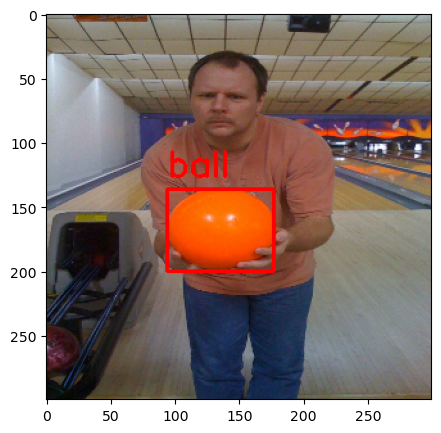

In [7]:
dataset = MyDataset(
    image_dir=IMAGE_PATH,
    annotations=ANNOT_VAL_PATH,
)
data_loader = MyDataLoader(
    dataset=dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
)
images_batch, labels_batch = next(iter(data_loader))
image_to_visualize = images_batch[0]
labels_to_visualize = labels_batch[0]
visualize(image_to_visualize, labels_to_visualize)

simple augmentations

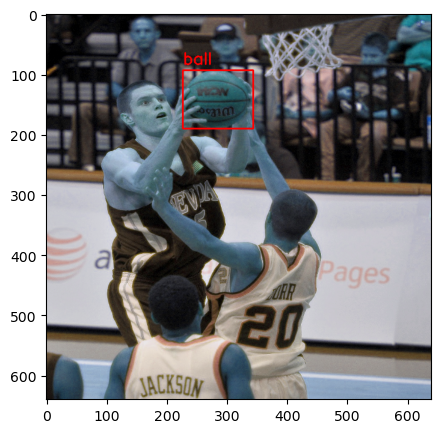

In [10]:
bbox_params = A.BboxParams(format='pascal_voc', label_fields=['class_labels'])
transforms = A.Compose(
    [
        A.Resize(640, 640),
        A.ColorJitter(p=0.5),
        A.GaussianBlur(sigma_limit=10),
        A.ToTensorV2()
    ], bbox_params=bbox_params
)
dataset = MyDataset(
    image_dir=IMAGE_PATH,
    annotations=ANNOT_VAL_PATH,
    transforms=transforms
)
data_loader = MyDataLoader(
    dataset=dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
)
images_batch, labels_batch = next(iter(data_loader))
image_to_visualize = images_batch[0]
labels_for_first_image = labels_batch[0]
visualize(image_to_visualize, labels_for_first_image)

not so simple augmentations

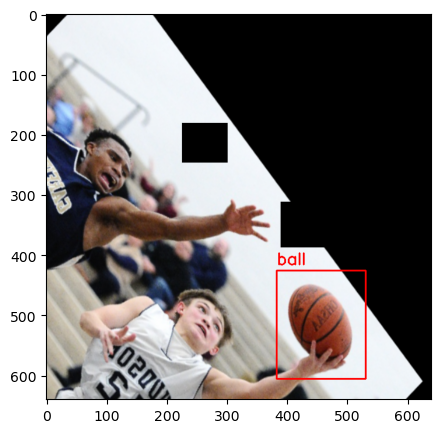

In [40]:
bbox_params = A.BboxParams(format='pascal_voc', label_fields=['class_labels'])
transforms = A.Compose(
    [
        A.Resize(640, 640),
        A.Affine(rotate=(-90, 90), translate_percent=0.3, p=1.0),
        A.RandomSizedBBoxSafeCrop(width=640, height=640, erosion_rate=0.2, p=0.5),
        A.HorizontalFlip(p=0.5),
        A.CoarseDropout(p=0.5),
        A.ToTensorV2(),
    ], bbox_params=bbox_params
)
dataset = MyDataset(
    image_dir=IMAGE_PATH,
    annotations=ANNOT_VAL_PATH,
    transforms=transforms
)
data_loader = MyDataLoader(
    dataset=dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
)
images_batch, labels_batch = next(iter(data_loader))
image_to_visualize = images_batch[0]
labels_for_first_image = labels_batch[0]
visualize(image_to_visualize, labels_for_first_image)

train

In [85]:
def train(train_loader, val_loader, epochs=10, weights=SSD300_VGG16_Weights.DEFAULT):
    model = ssd300_vgg16(weights=weights)
    in_channels = []
    for layer in model.head.classification_head.module_list:
        in_channels.append(layer.in_channels)
    num_classes = 2
    num_anchors = model.anchor_generator.num_anchors_per_location()

    new_head = SSDHead(
        in_channels=in_channels,
        num_anchors=num_anchors,
        num_classes=num_classes
    )
    model.head = new_head

    metric = MeanAveragePrecision(box_format='xyxy')
    train_losses = []
    val_maps = []
    val_epochs = []


    device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
    model.to(device)

    params = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.SGD(params, lr=0.0005, momentum=0.9, weight_decay=0.0005)
    model.train()
    for epoch in range(epochs):
        train_loss = 0.0
        for images, targets in train_loader:
            images = list(image.to(device) for image in images)
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
            losses_dict = model(images, targets)
            loss = sum(loss for loss in losses_dict.values())
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
        train_losses.append(train_loss / len(train_loader))
        print(f"Epoch {epoch}: train loss = {train_loss / len(train_loader):.4f}")
        if epoch % 2 == 0:
            model.eval()
            with torch.no_grad():
                for images, targets in val_loader:
                    images = list(image.to(device) for image in images)
                    targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
                    pred = model(images)
                    metric.update(pred, targets)
            results = metric.compute()
            val_maps.append(results['map'].item())
            val_epochs.append(epoch)
            print(f"Epoch {epoch}: Validation mAP = {results['map'].item():.4f}")
            metric.reset()
            model.train()
        print(epoch)
    torch.save(model.state_dict(), 'ssd_weights.pth')
    print('weights saved')
    graphics(train_losses, val_maps, val_epochs)
    return train_losses, val_maps, val_epochs

def inference(val_loader):
    model_inference = ssd300_vgg16(num_classes=2, weights=None)
    model_inference.load_state_dict(torch.load('ssd_weights.pth', weights_only=True))
    device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
    model_inference.to(device)
    model_inference.eval()

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    axes=axes.flatten()

    images_batch, labels_batch = next(iter(val_loader))
    for i in range(BATCH_SIZE):
        ax = axes[i]
        image_to_visualize = images_batch[i]
        ground_truth_labels = labels_batch[i]
        image_input = image_to_visualize.to(device)
        with torch.no_grad():
            predictions_list = model_inference([image_input])

        raw_predictions = predictions_list[0]
        score_threshold = 0.5
        keep_mask = raw_predictions['scores'] > score_threshold

        filtered_boxes = raw_predictions['boxes'][keep_mask]
        filtered_labels = raw_predictions['labels'][keep_mask]
        filtered_scores = raw_predictions['scores'][keep_mask]

        predictions_dict = {
            'boxes': filtered_boxes,
            'labels': filtered_labels,
            'scores': filtered_scores
        }
        visualize(image_to_visualize, predictions_dict, ax=ax)
    plt.show()

def graphics(train_losses, val_maps, val_epochs):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    ax1.plot(train_losses, label='Training Loss')
    ax1.set_title("Loss")
    ax1.set_xlabel("epoch")
    ax1.set_ylabel("Loss")
    ax1.grid(True)
    ax1.legend()
    ax2.plot(val_epochs, val_maps, label='Validation mAP', color='orange')
    ax2.set_title("График mAP на валидации")
    ax2.set_xlabel("epoch")
    ax2.set_ylabel("mAP")
    ax2.grid(True)
    ax2.legend()

    plt.tight_layout()
    plt.show()

Epoch 0: train loss = 7.0568
Epoch 0: Validation mAP = 0.0333
0
Epoch 1: train loss = 5.7005
1
Epoch 2: train loss = 5.2392
Epoch 2: Validation mAP = 0.1465
2
Epoch 3: train loss = 4.4692
3
Epoch 4: train loss = 4.2798
Epoch 4: Validation mAP = 0.2365
4
Epoch 5: train loss = 3.7831
5
Epoch 6: train loss = 3.3884
Epoch 6: Validation mAP = 0.2785
6
Epoch 7: train loss = 3.2377
7
Epoch 8: train loss = 2.7930
Epoch 8: Validation mAP = 0.3573
8
Epoch 9: train loss = 2.6254
9
weights saved


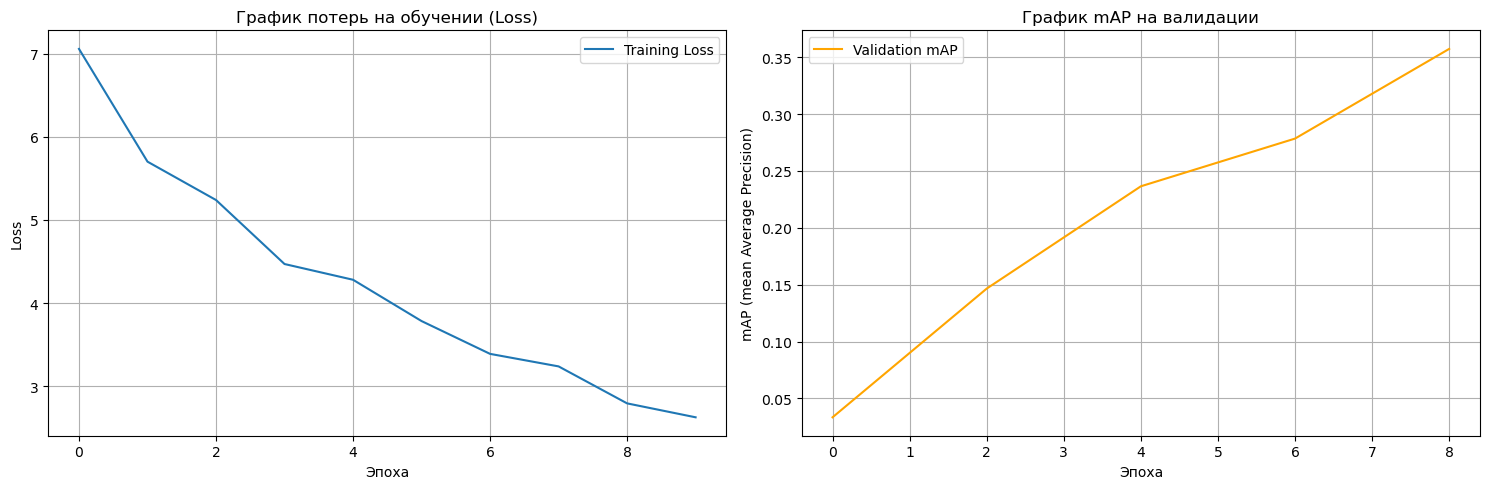

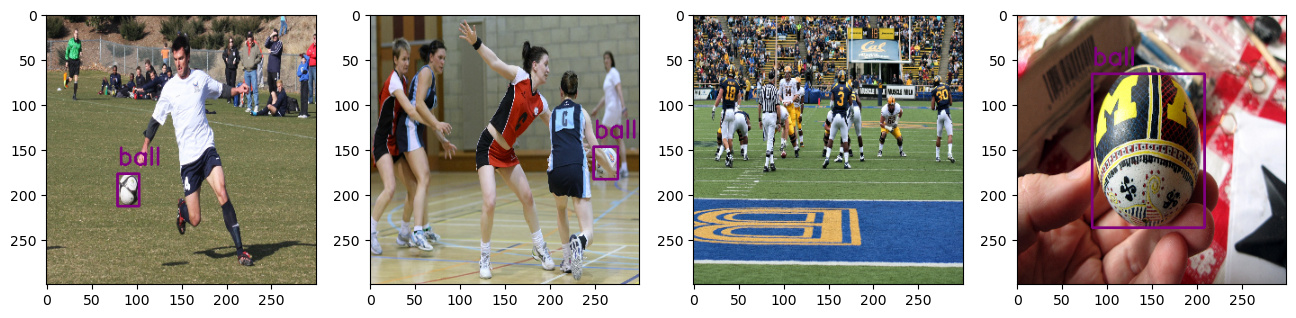

In [78]:
train_dataset = MyDataset(
    image_dir=IMAGE_PATH,
    annotations=ANNOT_VAL_PATH,
)
train_loader = MyDataLoader(
    dataset=train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
)
val_dataset = MyDataset(
    image_dir=IMAGE_PATH,
    annotations=ANNOT_VAL_PATH,
)
val_loader = MyDataLoader(
    dataset=val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
)
info_baseline = train(train_loader, val_loader)
inference(val_loader)

without pretraining

Epoch 0: train loss = 12.4548
Epoch 0: Validation mAP = 0.0012
0
Epoch 1: train loss = 13.6604
1
Epoch 2: train loss = nan
Epoch 2: Validation mAP = 0.0000
2
Epoch 3: train loss = nan
3
Epoch 4: train loss = nan
Epoch 4: Validation mAP = 0.0000
4
Epoch 5: train loss = nan
5
Epoch 6: train loss = nan
Epoch 6: Validation mAP = 0.0000
6
Epoch 7: train loss = nan
7
Epoch 8: train loss = nan
Epoch 8: Validation mAP = 0.0000
8
Epoch 9: train loss = nan
9
weights saved


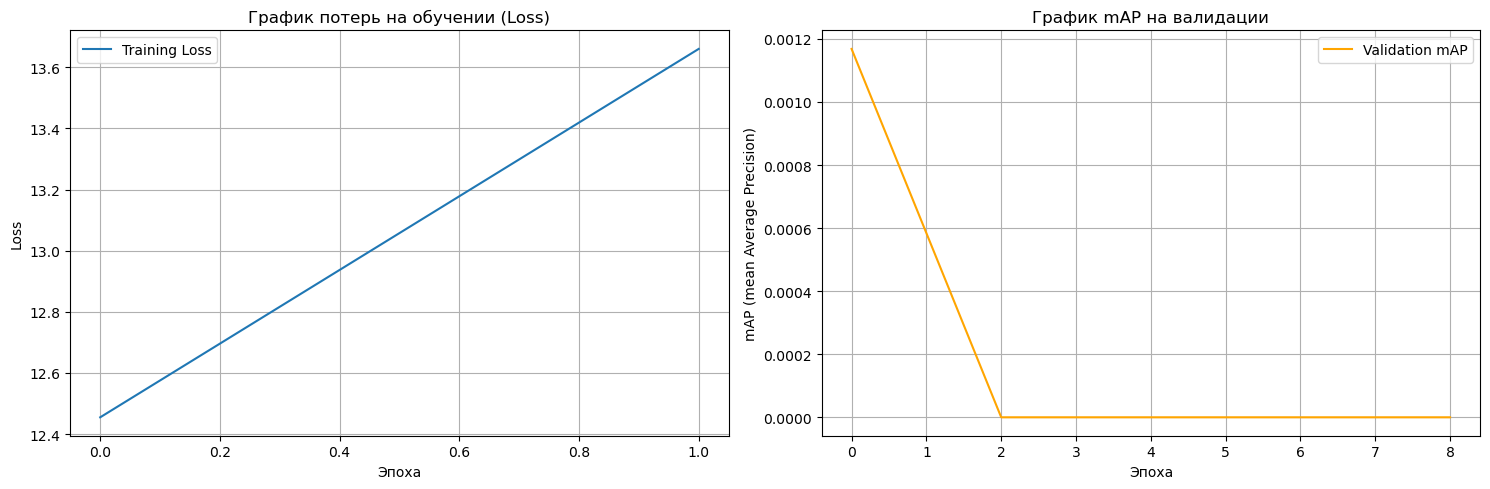

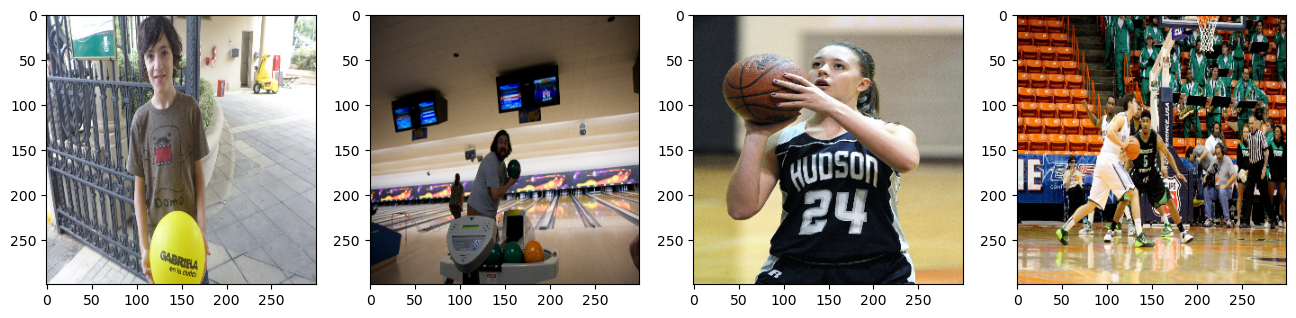

In [86]:
info_baseline_not_pretrained = train(train_loader, val_loader, weights=None)
inference(val_loader)

with simple augs

Epoch 0: train loss = 7.0692
Epoch 0: Validation mAP = 0.0046
0
Epoch 1: train loss = 5.9304
1
Epoch 2: train loss = 5.7732
Epoch 2: Validation mAP = 0.0328
2
Epoch 3: train loss = 5.5787
3
Epoch 4: train loss = 5.4935
Epoch 4: Validation mAP = 0.0614
4
Epoch 5: train loss = 5.0981
5
Epoch 6: train loss = 4.9241
Epoch 6: Validation mAP = 0.1442
6
Epoch 7: train loss = 4.7291
7
Epoch 8: train loss = 4.5493
Epoch 8: Validation mAP = 0.1638
8
Epoch 9: train loss = 4.5424
9
weights saved


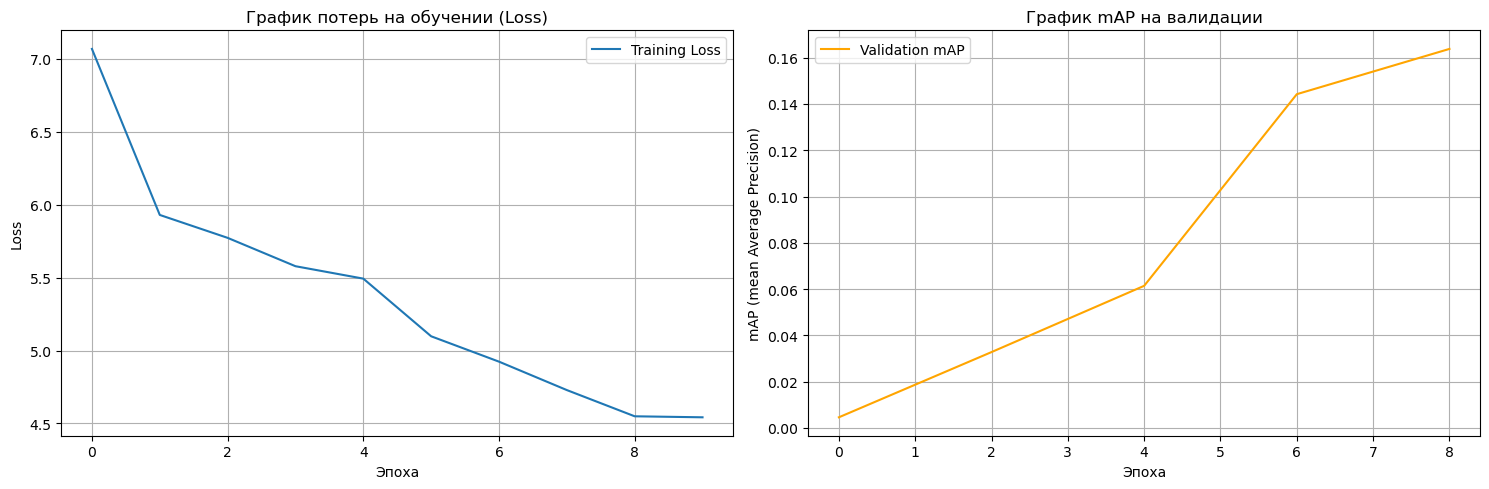

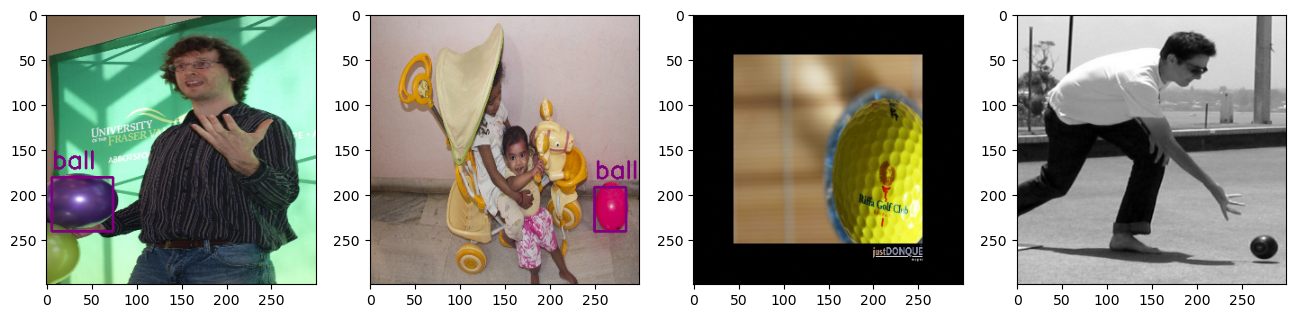

In [81]:
bbox_params = A.BboxParams(format='pascal_voc', label_fields=['class_labels'])
transforms = A.Compose(
    [
        A.Resize(300, 300),
        A.ColorJitter(p=0.5),
        A.GaussianBlur(sigma_limit=5, p=0.5),
        A.ToTensorV2()
    ], bbox_params=bbox_params
)
train_dataset = MyDataset(
    image_dir=IMAGE_PATH,
    annotations=ANNOT_VAL_PATH,
    transforms=transforms
)
train_loader = MyDataLoader(
    dataset=train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
)
val_dataset = MyDataset(
    image_dir=IMAGE_PATH,
    annotations=ANNOT_VAL_PATH,
)
val_loader = MyDataLoader(
    dataset=val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
)
info_simple_augs = train(train_loader, val_loader)
inference(val_loader)

with not so simple augs

Epoch 0: train loss = 6.6378
Epoch 0: Validation mAP = 0.0079
0
Epoch 1: train loss = 5.5153
1
Epoch 2: train loss = 5.2014
Epoch 2: Validation mAP = 0.0512
2
Epoch 3: train loss = 5.2367
3
Epoch 4: train loss = 5.0022
Epoch 4: Validation mAP = 0.0976
4
Epoch 5: train loss = 4.8796
5
Epoch 6: train loss = 4.5606
Epoch 6: Validation mAP = 0.1471
6
Epoch 7: train loss = 4.4917
7
Epoch 8: train loss = 4.5176
Epoch 8: Validation mAP = 0.1529
8
Epoch 9: train loss = 4.1772
9
weights saved


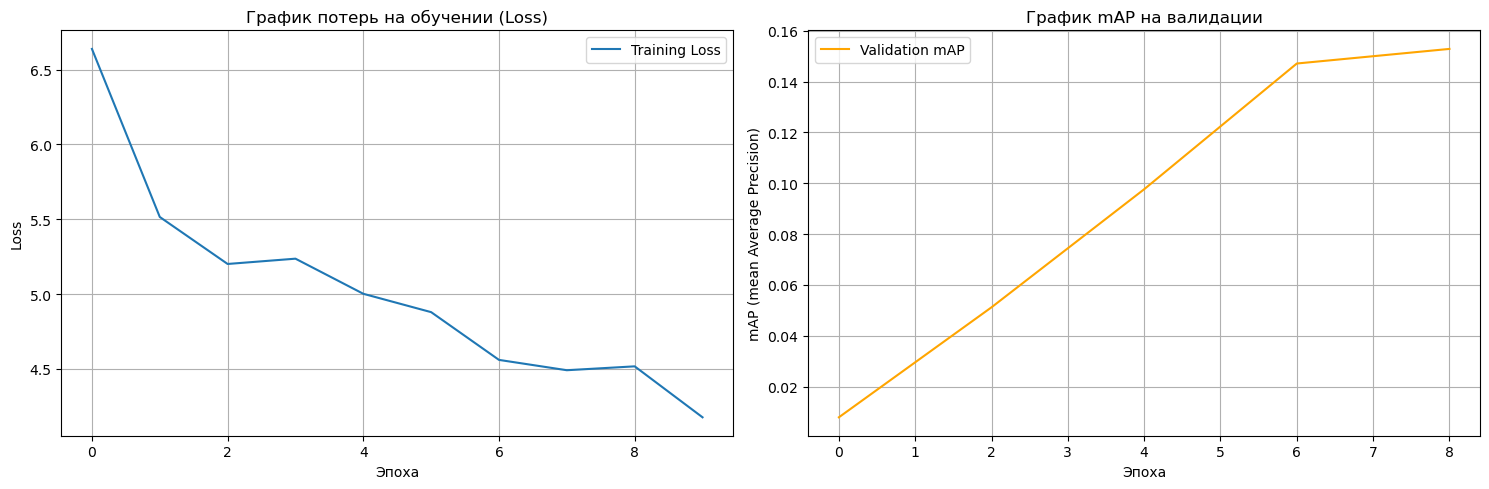

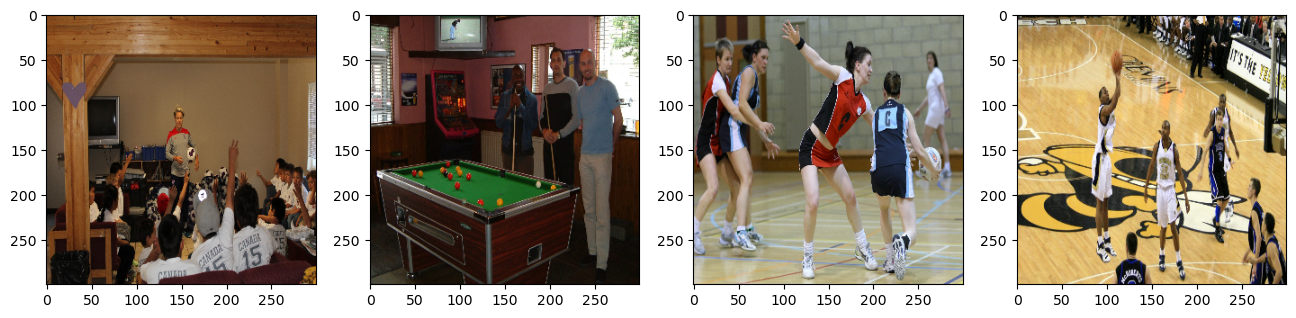

In [82]:
bbox_params = A.BboxParams(format='pascal_voc', label_fields=['class_labels'])
transforms = A.Compose(
    [
        A.Resize(300, 300),
        A.Affine(rotate=(-45, 45), translate_percent=0.15, p=0.5),
        A.RandomSizedBBoxSafeCrop(width=640, height=640, erosion_rate=0.2, p=0.5),
        A.HorizontalFlip(p=0.5),
        A.CoarseDropout(p=0.5),
        A.ToTensorV2(),
    ], bbox_params=bbox_params
)
train_dataset = MyDataset(
    image_dir=IMAGE_PATH,
    annotations=ANNOT_VAL_PATH,
    transforms=transforms
)
train_loader = MyDataLoader(
    dataset=train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
)
val_dataset = MyDataset(
    image_dir=IMAGE_PATH,
    annotations=ANNOT_VAL_PATH,
)
val_loader = MyDataLoader(
    dataset=val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
)
info_not_simple_augs = train(train_loader, val_loader)
inference(val_loader)

# выводы
  - узким местом является грубое приведение к разрешению 300x300 (на таких картинках была предобучена модель). какие-то шары размазываются. бильярдные были маленькими и стали еще меньше
- с аугментациями модели видимо нужно больше эпох
- предобучение важная штука
-